In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Better figure size for all plots
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
apps = pd.read_excel(r"C:\Users\admin\Downloads\Google Play Store Analysis\Googleplaystore_cleaned.xlsx")
reviews = pd.read_excel(r"C:\Users\admin\Downloads\Google Play Store Analysis\googleplaystore_user_reviews.xlsx")

<function matplotlib.pyplot.show(close=None, block=None)>

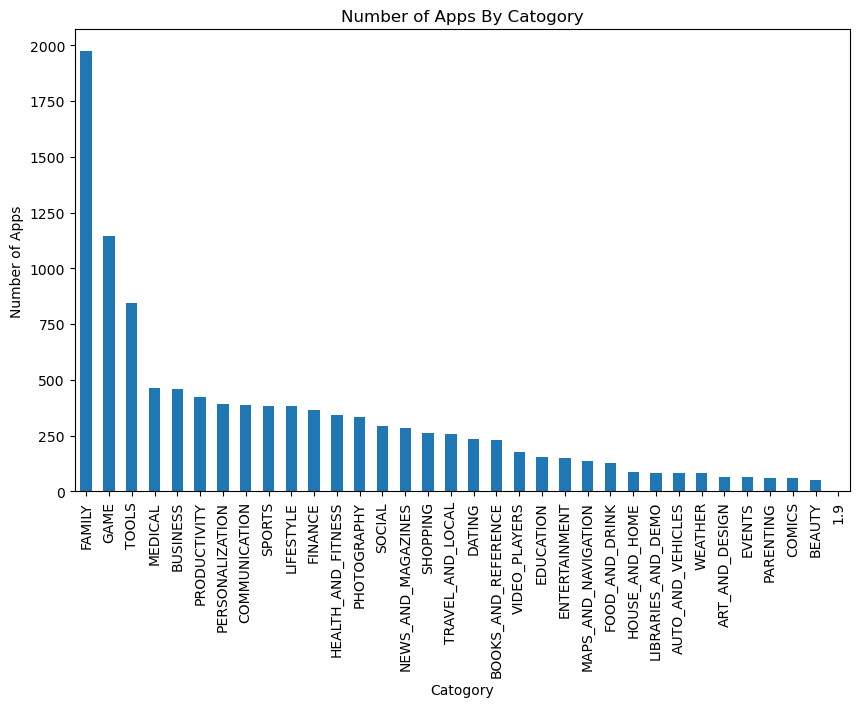

In [4]:
# Distribution of App Categories
Category_count = apps['Category'].value_counts()

Category_count.plot(kind='bar')

plt.title("Number of Apps By Catogory")
plt.xlabel("Catogory")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)

plt.show

The Family and Game categories are highly competitive.

In [5]:
# Check data types
print(apps.dtypes)

App                       object
Category                  object
Rating                   float64
Reviews                  float64
Size                     float64
Installs                 float64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
dtype: object


In [47]:
#Average Rating by Category
avg_rating = (
    apps.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_rating.index)

Index([                  1.9,              'EVENTS',           'EDUCATION',
            'ART_AND_DESIGN', 'BOOKS_AND_REFERENCE',     'PERSONALIZATION',
                 'PARENTING',                'GAME',              'BEAUTY',
        'HEALTH_AND_FITNESS',            'SHOPPING',              'SOCIAL',
                   'WEATHER',              'SPORTS',        'PRODUCTIVITY',
                   'MEDICAL',      'HOUSE_AND_HOME',  'LIBRARIES_AND_DEMO',
         'AUTO_AND_VEHICLES',              'FAMILY',         'PHOTOGRAPHY',
            'FOOD_AND_DRINK',            'BUSINESS',       'COMMUNICATION',
        'NEWS_AND_MAGAZINES',              'COMICS',             'FINANCE',
          'TRAVEL_AND_LOCAL',           'LIFESTYLE',       'ENTERTAINMENT',
             'VIDEO_PLAYERS',               'TOOLS', 'MAPS_AND_NAVIGATION',
                    'DATING'],
      dtype='object', name='Category')


In [48]:
apps["Category"] = apps["Category"].astype(str)

apps = apps[apps["Category"] != "1.9"]

In [49]:
avg_rating = (
    apps.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_rating.index)

Index(['EVENTS', 'EDUCATION', 'ART_AND_DESIGN', 'BOOKS_AND_REFERENCE',
       'PERSONALIZATION', 'PARENTING', 'GAME', 'BEAUTY', 'HEALTH_AND_FITNESS',
       'SHOPPING', 'SOCIAL', 'WEATHER', 'SPORTS', 'PRODUCTIVITY', 'MEDICAL',
       'HOUSE_AND_HOME', 'LIBRARIES_AND_DEMO', 'AUTO_AND_VEHICLES', 'FAMILY',
       'PHOTOGRAPHY', 'FOOD_AND_DRINK', 'BUSINESS', 'COMMUNICATION',
       'NEWS_AND_MAGAZINES', 'COMICS', 'FINANCE', 'TRAVEL_AND_LOCAL',
       'LIFESTYLE', 'ENTERTAINMENT', 'VIDEO_PLAYERS', 'TOOLS',
       'MAPS_AND_NAVIGATION', 'DATING'],
      dtype='object', name='Category')


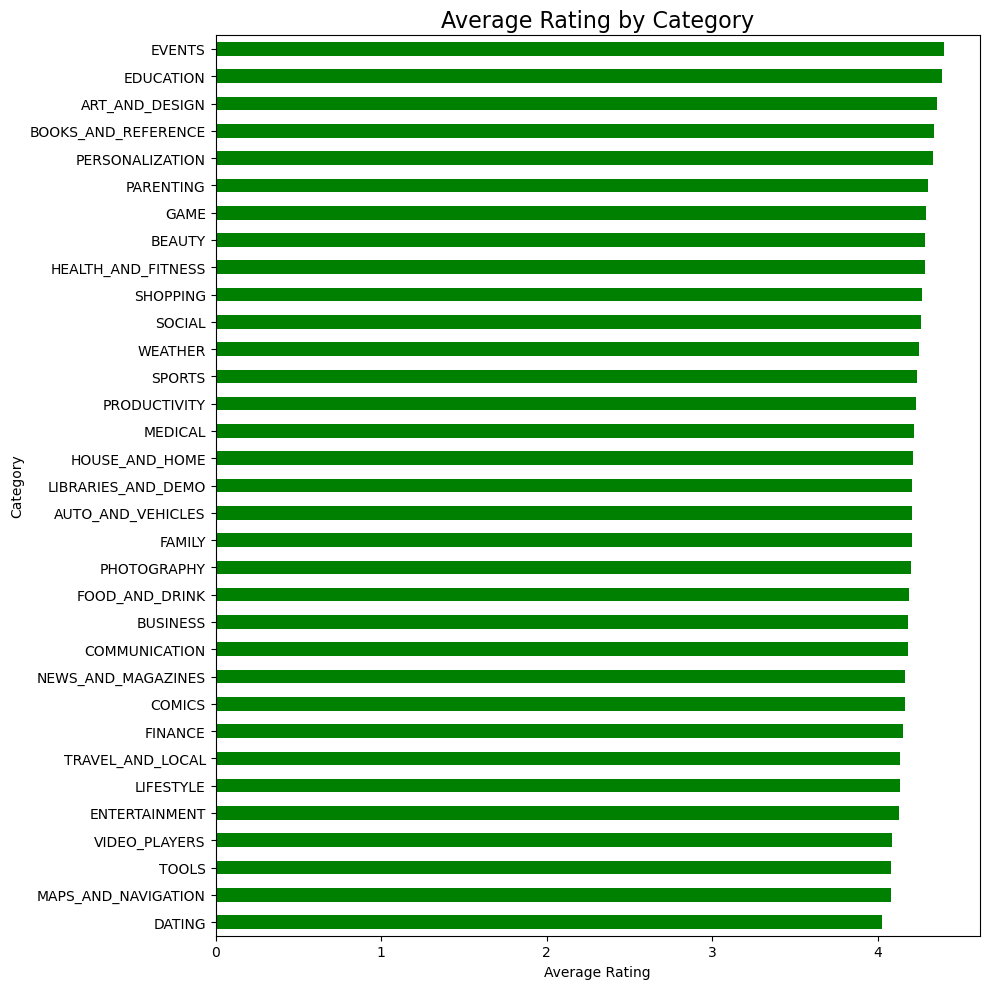

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

avg_rating.sort_values().plot(kind="barh", color="green")

plt.title("Average Rating by Category", fontsize=16)
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

Events categorie receive the highest user ratings.

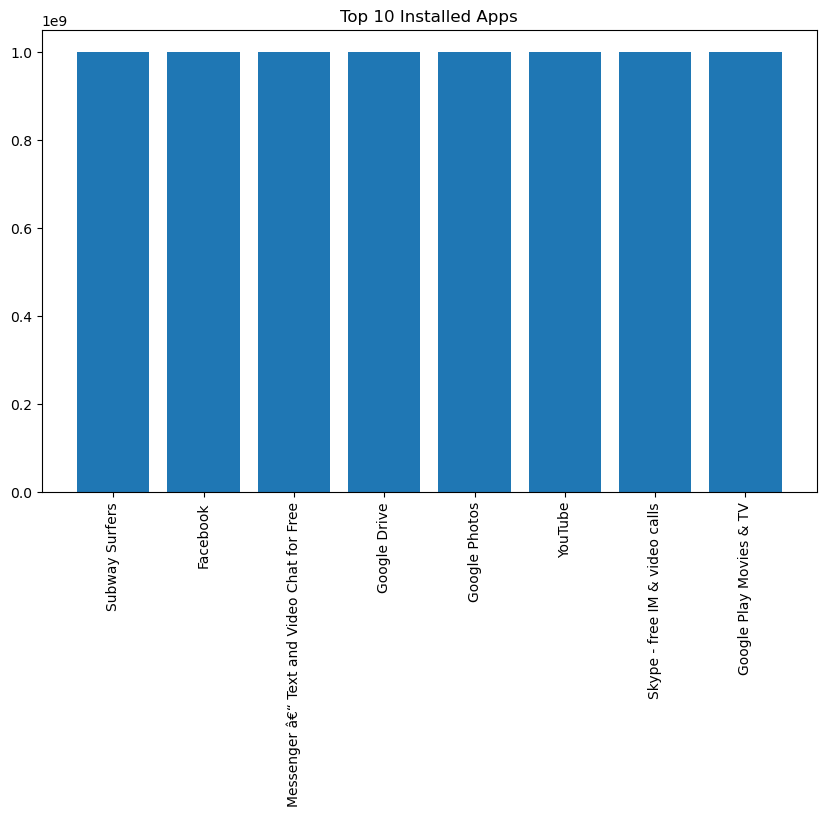

In [51]:
#Top 10 Most Installed Apps
top_apps = apps.sort_values('Installs', ascending=False).head(10)

plt.bar(top_apps['App'], top_apps['Installs'])

plt.xticks(rotation=90)

plt.title("Top 10 Installed Apps")

plt.show()

Google applications dominate the top installs.



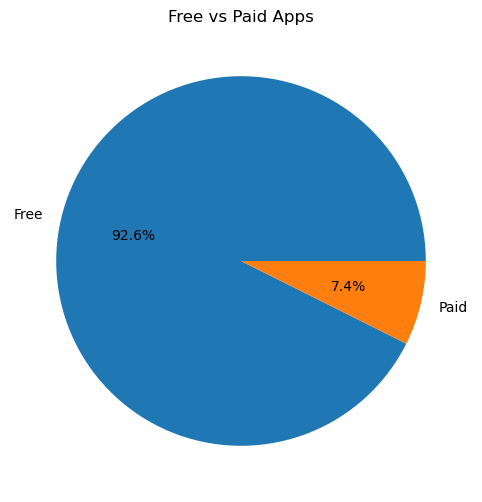

In [52]:
#compare Free vs Paid Apps
apps['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Free vs Paid Apps")

plt.ylabel("")

plt.show()

More than 90% of apps are free.

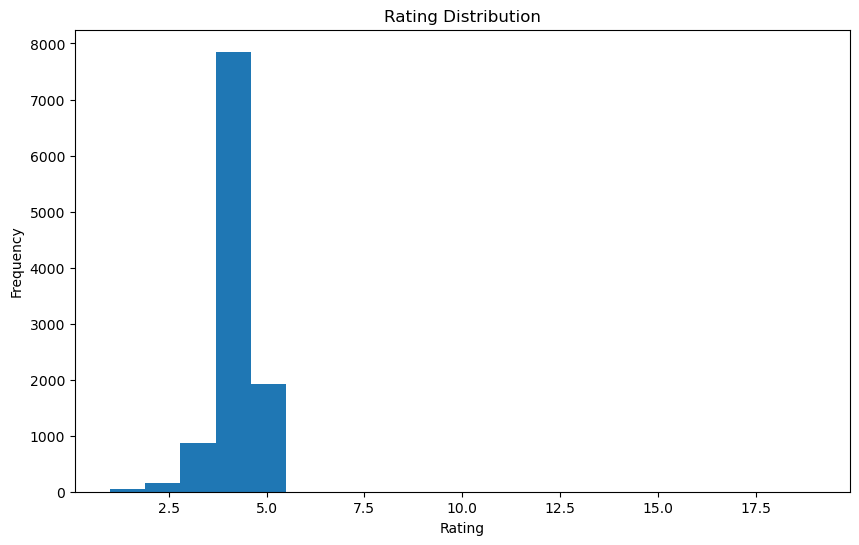

In [6]:
#Rating Distribution
plt.hist(apps['Rating'].dropna(), bins=20)

plt.title("Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

Most ratings lie between 4.0 and 4.5.

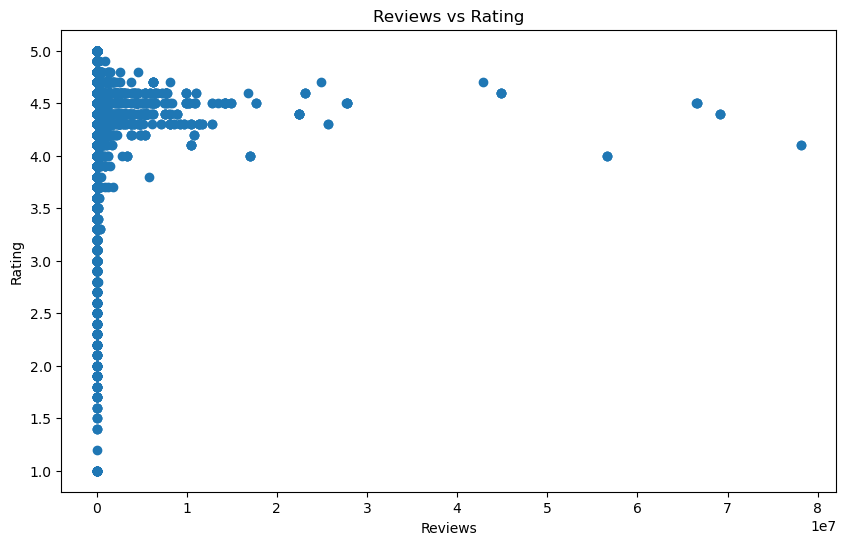

In [8]:
#Reviews vs Rating
plt.scatter(apps['Reviews'], apps['Rating'])
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Rating")
plt.show()

A few apps have high ratings despite having zero reviews.

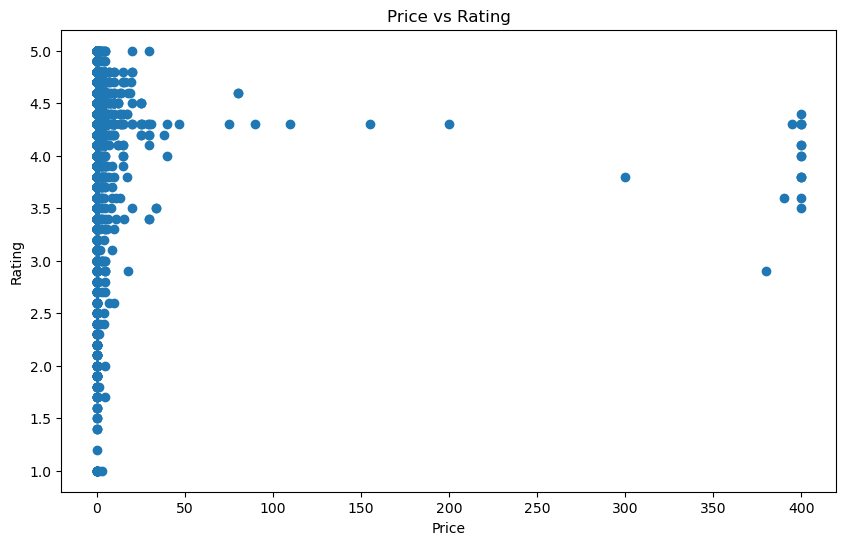

In [19]:
#Price vs apps 
paid_apps = apps[apps['Type'] == 'Paid']
paid_apps= apps[apps['Price'] > 0]
plt.scatter(apps['Price'], apps['Rating'])
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

Most apps are free or low-priced, so most points are close to Price = 0.Increasing the app price does not guarantee a higher rating. Users rate apps based on their quality, usefulness, and experience rather than their price.

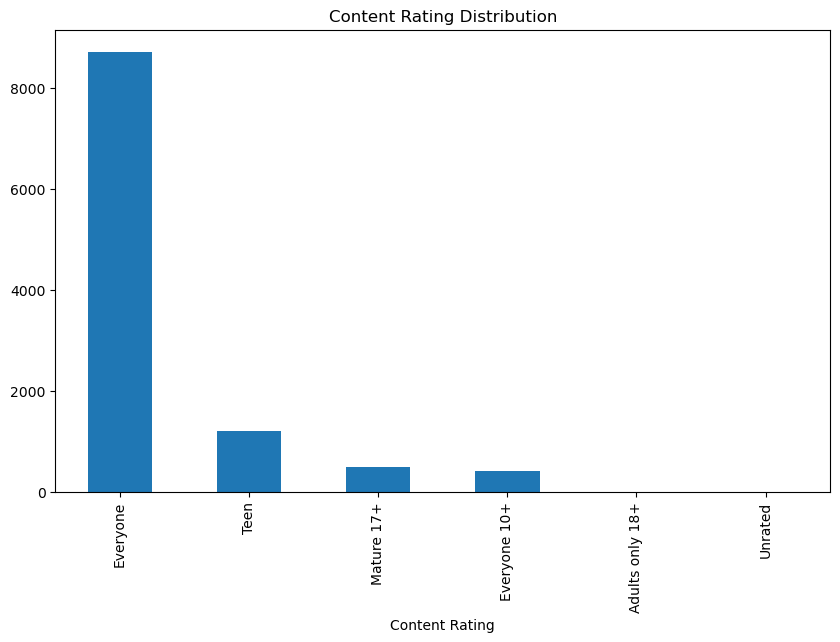

In [20]:
#Content Rating Distribution
apps['Content Rating'].value_counts().plot(kind='bar')

plt.title("Content Rating Distribution")

plt.show()

Everyone is the largest audience segment.

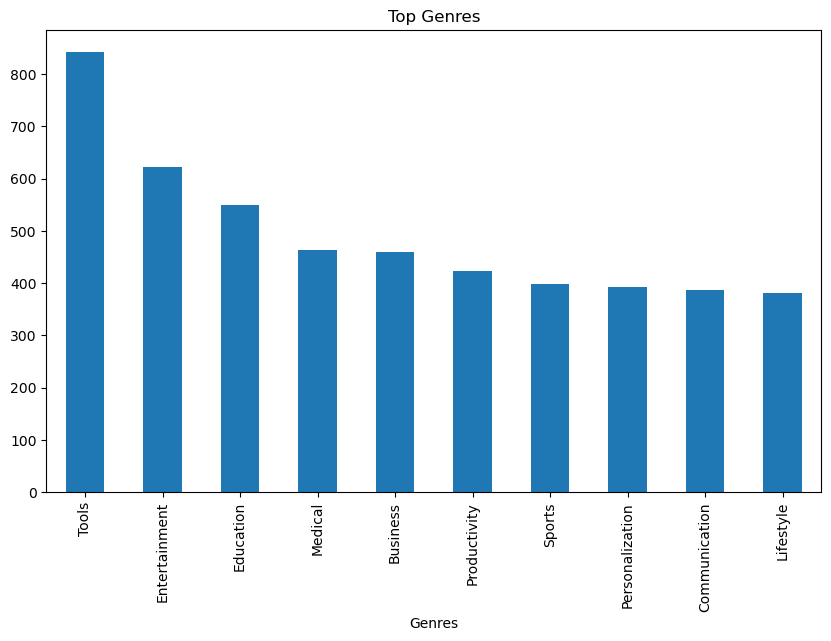

In [21]:
#Genre Distribution
apps['Genres'].value_counts().head(10).plot(kind='bar')

plt.title("Top Genres")

plt.show()

Tools and Entertainment are among the most common genres.These genres have high competition, requiring strong feature differentiation.

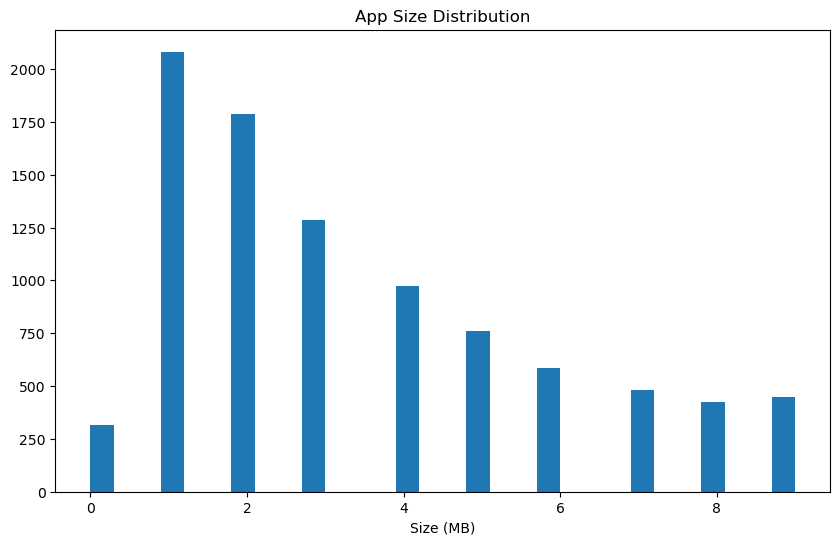

In [22]:
#App Size Distribution
plt.hist(apps['Size'].dropna(), bins=30)

plt.title("App Size Distribution")

plt.xlabel("Size (MB)")

plt.show()

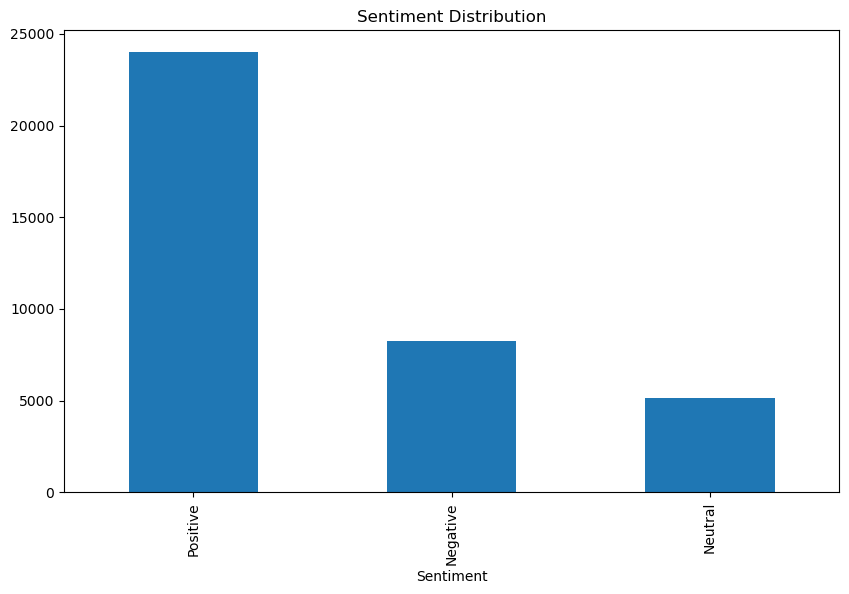

In [23]:
#Sentiment Distribution
reviews['Sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")

plt.show()

Positive reviews dominate.

In [24]:
#Sentiment by App Category
merged = pd.merge(
    reviews,
    apps[['App', 'Category']],
    on='App',
    how='inner'
)

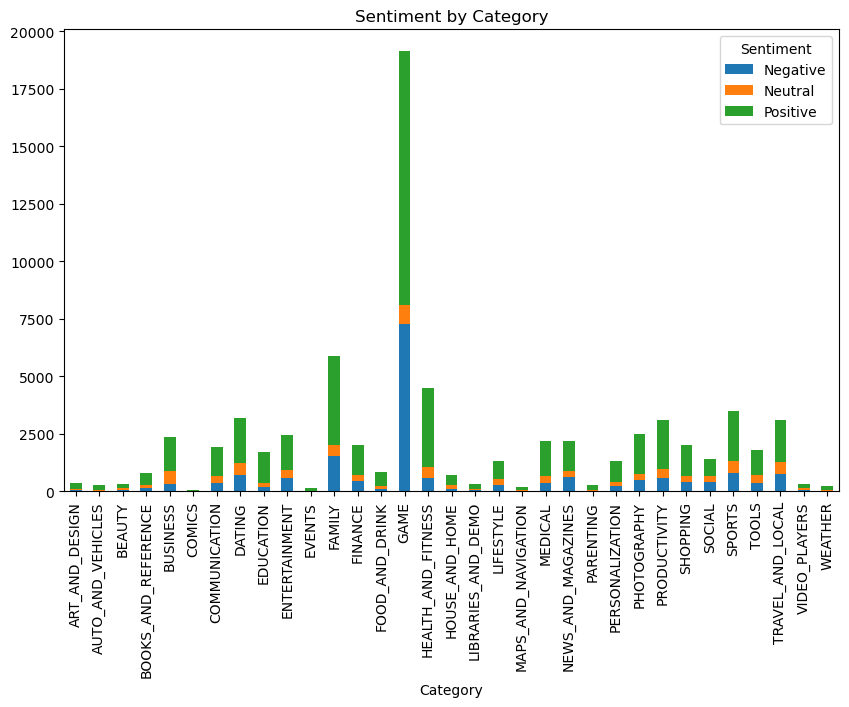

In [25]:
sentiment = pd.crosstab(
    merged['Category'],
    merged['Sentiment']
)

sentiment.plot(kind='bar', stacked=True)

plt.title("Sentiment by Category")

plt.show()

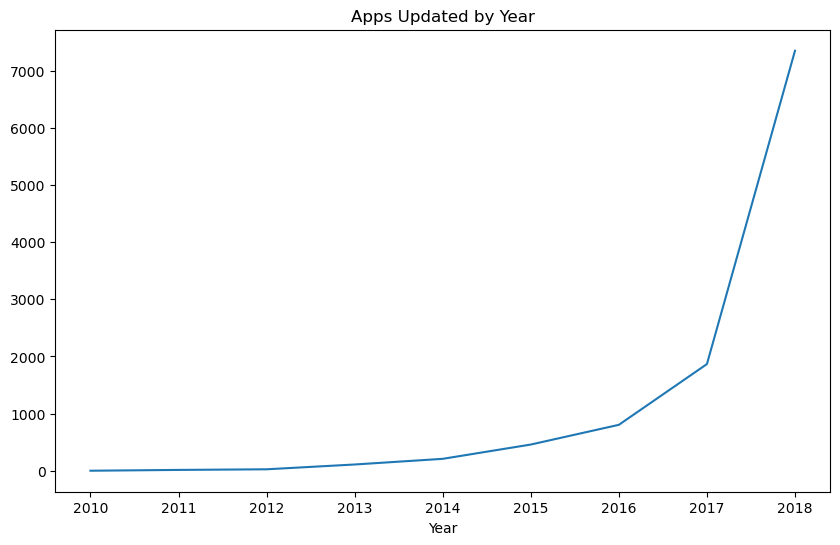

In [26]:
#Apps Updated Over Time
apps['Year'] = pd.to_datetime(apps['Last Updated']).dt.year

apps['Year'].value_counts().sort_index().plot()

plt.title("Apps Updated by Year")

plt.show()

Frequent updates indicate active maintenance, which can improve user trust and app quality.

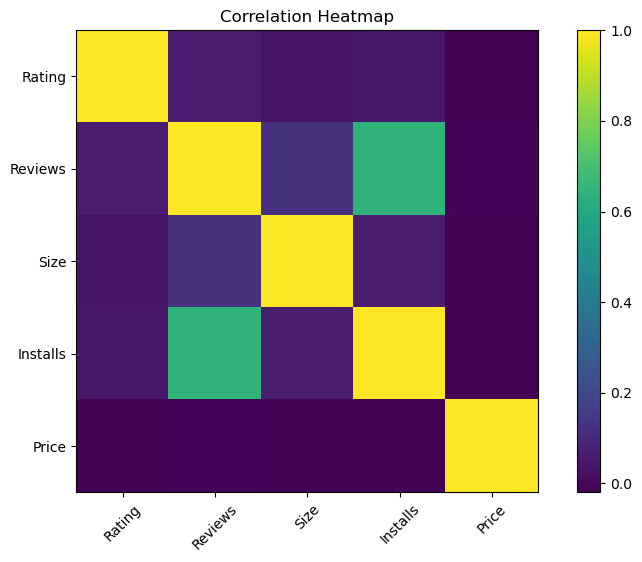

In [27]:
#Correlation Heatmap
corr = apps[['Rating', 'Reviews', 'Size', 'Installs', 'Price']].corr()

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

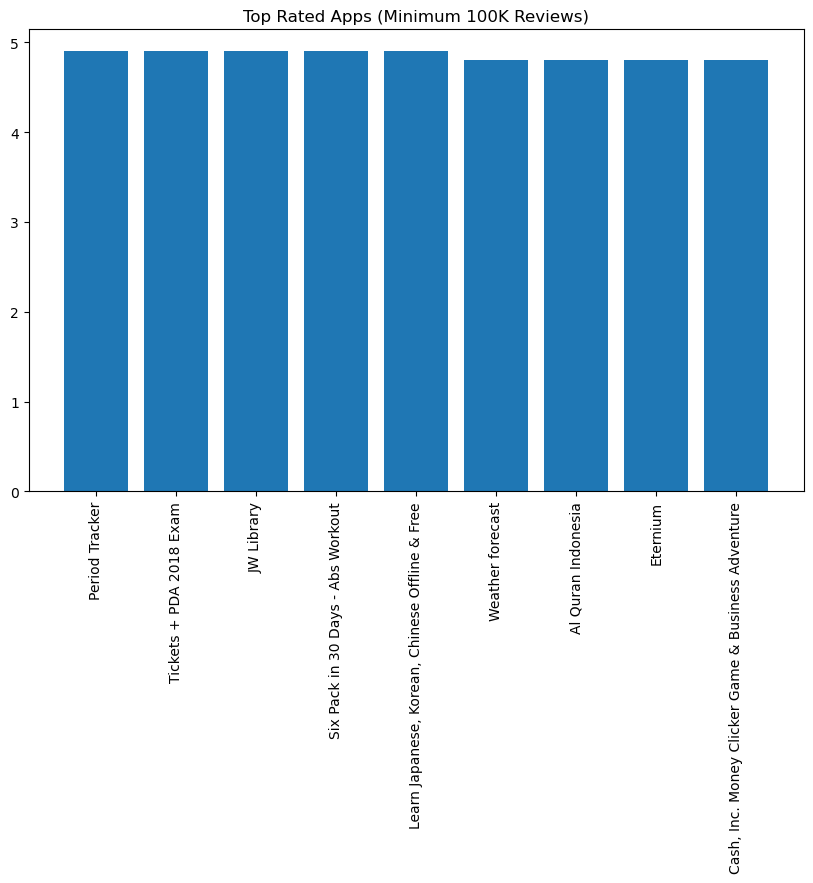

In [28]:
#Top 10 Highest Rated Apps
top_rated = apps[apps['Reviews'] >= 100000]

top_rated = top_rated.sort_values('Rating', ascending=False).head(10)

plt.bar(top_rated['App'], top_rated['Rating'])

plt.xticks(rotation=90)

plt.title("Top Rated Apps (Minimum 100K Reviews)")

plt.show()

Only a limited number of apps maintain very high ratings despite receiving a large volume of reviews.High ratings combined with many reviews indicate consistently strong user satisfaction and product quality.